# Anime-Erfolg klassifizieren & Empfehlungssystem

**Datensatz:** MyAnimeList 2020 – 17.562 Anime-Einträge  
**Ziele:**
1. **Klassifikation** – Welche Eigenschaften machen einen Anime „Top-Rated" (Score > 8.0)?
2. **Clustering** – Welche inhaltlich ähnlichen Anime-Gruppen gibt es, und wie lassen sich daraus Empfehlungen ableiten?

In [122]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/anime.csv')
df

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678,329800,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,"Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770,57964,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925,146918,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378,33719,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,"TV Tokyo, Dentsu",Unknown,Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108,3394,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,Unknown,"Adventure, Mystery, Supernatural",Unknown,盗墓笔记之秦岭神树,ONA,Unknown,"Apr 4, 2021 to ?",Unknown,Unknown,Unknown,Unknown,Novel,Unknown,Unknown,Unknown,13116,354,6,0,0,0,0,354,Unknown,Unknown,Unknown,1.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
17558,48483,Mieruko-chan,Unknown,"Comedy, Horror, Supernatural",Unknown,見える子ちゃん,TV,Unknown,2021 to ?,Unknown,Kadokawa,Unknown,Passione,Manga,Unknown,Unknown,Unknown,17562,7010,70,14,0,14,0,6982,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
17559,48488,Higurashi no Naku Koro ni Sotsu,Unknown,"Mystery, Dementia, Horror, Psychological, Supe...",Higurashi:When They Cry – SOTSU,ひぐらしのなく頃に卒,TV,Unknown,"Jul, 2021 to ?",Summer 2021,Unknown,Unknown,Unknown,Visual novel,Unknown,R - 17+ (violence & profanity),Unknown,17558,11309,48,3,0,0,0,11306,1.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
17560,48491,Yama no Susume: Next Summit,Unknown,"Adventure, Slice of Life, Comedy",Unknown,ヤマノススメ Next Summit,TV,Unknown,Unknown,Unknown,Kadokawa,Unknown,8bit,Manga,Unknown,PG-13 - Teens 13 or older,Unknown,17565,1386,2,13,2,2,1,1368,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown


In [123]:
df.describe()

,MAL_ID,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch
count,17562.000000,17562.000000,1.756200e+04,17562.000000,17562.000000,1.756200e+04,17562.000000,17562.000000,17562.000000
mean,21477.192347,8763.452340,3.465854e+04,457.746270,2231.487758,2.209557e+04,955.049653,1176.599533,8199.831227
std,14900.093170,5059.327278,1.252821e+05,4063.473313,14046.688133,9.100919e+04,4275.675096,4740.348653,23777.691963
min,1.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000
25%,5953.500000,4383.500000,3.360000e+02,0.000000,13.000000,1.110000e+02,6.000000,37.000000,112.000000
50%,22820.000000,8762.500000,2.065000e+03,3.000000,73.000000,8.175000e+02,45.000000,77.000000,752.500000
75%,35624.750000,13145.000000,1.322325e+04,31.000000,522.000000,6.478000e+03,291.750000,271.000000,4135.500000
max,48492.000000,17565.000000,2.589552e+06,183914.000000,887333.000000,2.182587e+06,187919.000000,174710.000000,425531.000000


In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   MAL_ID         17562 non-null  int64
 1   Name           17562 non-null  str  
 2   Score          17562 non-null  str  
 3   Genres         17562 non-null  str  
 4   English name   17562 non-null  str  
 5   Japanese name  17562 non-null  str  
 6   Type           17562 non-null  str  
 7   Episodes       17562 non-null  str  
 8   Aired          17562 non-null  str  
 9   Premiered      17562 non-null  str  
 10  Producers      17562 non-null  str  
 11  Licensors      17562 non-null  str  
 12  Studios        17562 non-null  str  
 13  Source         17562 non-null  str  
 14  Duration       17562 non-null  str  
 15  Rating         17562 non-null  str  
 16  Ranked         17562 non-null  str  
 17  Popularity     17562 non-null  int64
 18  Members        17562 non-null  int64
 19  Favorites      

In [125]:
df.isna().sum()

MAL_ID           0
Name             0
Score            0
Genres           0
English name     0
Japanese name    0
Type             0
Episodes         0
Aired            0
Premiered        0
Producers        0
Licensors        0
Studios          0
Source           0
Duration         0
Rating           0
Ranked           0
Popularity       0
Members          0
Favorites        0
Watching         0
Completed        0
On-Hold          0
Dropped          0
Plan to Watch    0
Score-10         0
Score-9          0
Score-8          0
Score-7          0
Score-6          0
Score-5          0
Score-4          0
Score-3          0
Score-2          0
Score-1          0
dtype: int64

In [126]:
import numpy as np 

df = df.replace('Unknown', np.nan)

## 1. Datensatz & Bereinigung

`Unknown`-Strings werden durch `NaN` ersetzt, danach werden numerische Spalten (Score, Episodes, Ranked) korrekt konvertiert.

In [127]:
df.isna().sum()

MAL_ID               0
Name                 0
Score             5141
Genres              63
English name     10565
Japanese name       48
Type                37
Episodes           516
Aired              309
Premiered        12817
Producers         7794
Licensors        13616
Studios           7079
Source            3567
Duration           555
Rating             688
Ranked            1762
Popularity           0
Members              0
Favorites            0
Watching             0
Completed            0
On-Hold              0
Dropped              0
Plan to Watch        0
Score-10           437
Score-9           3167
Score-8           1371
Score-7            503
Score-6            511
Score-5            584
Score-4            977
Score-3           1307
Score-2           1597
Score-1            459
dtype: int64

In [128]:
df.nunique()

MAL_ID           17562
Name             17558
Score              532
Genres            5033
English name      6830
Japanese name    16678
Type                 6
Episodes           200
Aired            11946
Premiered          230
Producers         3782
Licensors          230
Studios           1089
Source              15
Duration           312
Rating               6
Ranked           10489
Popularity       11755
Members           9508
Favorites         1543
Watching          3580
Completed         7822
On-Hold           2915
Dropped           3035
Plan to Watch     7055
Score-10          3378
Score-9           3644
Score-8           4514
Score-7           4932
Score-6           4235
Score-5           3287
Score-4           2234
Score-3           1505
Score-2           1109
Score-1           1083
dtype: int64

In [129]:
df['Genres'].unique()

<StringArray>
[                'Action, Adventure, Comedy, Drama, Sci-Fi, Space',
                           'Action, Drama, Mystery, Sci-Fi, Space',
               'Action, Sci-Fi, Adventure, Comedy, Drama, Shounen',
             'Action, Mystery, Police, Supernatural, Drama, Magic',
                       'Adventure, Fantasy, Shounen, Supernatural',
                                 'Action, Sports, Comedy, Shounen',
                    'Comedy, Drama, Josei, Romance, Slice of Life',
                          'Slice of Life, Comedy, Sports, Shounen',
                             'Action, Cars, Sports, Drama, Seinen',
 'Drama, Horror, Mystery, Police, Psychological, Seinen, Thriller',
 ...
                                   'Mystery, Supernatural, School',
         'Mystery, Psychological, Supernatural, Thriller, Shounen',
                                                   'Fantasy, Yaoi',
                                           'Martial Arts, Fantasy',
                             

In [130]:
all_genres = df['Genres'].dropna().str.split(', ').explode()
print('Number of genres:',all_genres.nunique())
all_genres.value_counts()

Number of genres: 43


Genres
Comedy           6029
Action           3888
Fantasy          3285
Adventure        2957
Kids             2665
Drama            2619
Sci-Fi           2583
Music            2244
Shounen          2003
Slice of Life    1914
Romance          1899
School           1642
Supernatural     1479
Hentai           1348
Historical       1144
Mecha            1101
Magic            1081
Seinen            830
Ecchi             767
Mystery           727
Sports            713
Shoujo            688
Parody            660
Super Power       632
Military          576
Dementia          512
Demons            501
Space             495
Horror            462
Martial Arts      425
Harem             399
Game              386
Psychological     345
Police            247
Samurai           202
Vampire           136
Cars              133
Thriller          131
Shounen Ai        100
Josei              97
Shoujo Ai          79
Yaoi               42
Yuri               32
Name: count, dtype: int64

In [131]:
df

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678,329800,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",NaN,"Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770,57964,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925,146918,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378,33719,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,"TV Tokyo, Dentsu",NaN,Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108,3394,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,NaN,"Adventure, Mystery, Supernatural",NaN,盗墓笔记之秦岭神树,ONA,NaN,"Apr 4, 2021 to ?",NaN,NaN,NaN,NaN,Novel,NaN,NaN,NaN,13116,354,6,0,0,0,0,354,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
17558,48483,Mieruko-chan,NaN,"Comedy, Horror, Supernatural",NaN,見える子ちゃん,TV,NaN,2021 to ?,NaN,Kadokawa,NaN,Passione,Manga,NaN,NaN,NaN,17562,7010,70,14,0,14,0,6982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17559,48488,Higurashi no Naku Koro ni Sotsu,NaN,"Mystery, Dementia, Horror, Psychological, Supe...",Higurashi:When They Cry – SOTSU,ひぐらしのなく頃に卒,TV,NaN,"Jul, 2021 to ?",Summer 2021,NaN,NaN,NaN,Visual novel,NaN,R - 17+ (violence & profanity),NaN,17558,11309,48,3,0,0,0,11306,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17560,48491,Yama no Susume: Next Summit,NaN,"Adventure, Slice of Life, Comedy",NaN,ヤマノススメ Next Summit,TV,NaN,NaN,NaN,Kadokawa,NaN,8bit,Manga,NaN,PG-13 - Teens 13 or older,NaN,17565,1386,2,13,2,2,1,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
# Score und andere numerische Spalten zu Zahlen konvertieren
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')
df['Ranked'] = pd.to_numeric(df['Ranked'], errors='coerce')

# Score-Verteilungs-Spalten auch
score_cols = [f'Score-{i}' for i in range(1, 11)]
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Anime mit Score: {df['Score'].notna().sum()}")
print(f"Anime ohne Score: {df['Score'].isna().sum()}")
print(f"\nScore-Statistik:")
print(df['Score'].describe())

Anime mit Score: 12421
Anime ohne Score: 5141

Score-Statistik:
count    12421.000000
mean         6.509999
std          0.886717
min          1.850000
25%          5.930000
50%          6.520000
75%          7.140000
max          9.190000
Name: Score, dtype: float64


## 2. Explorative Datenanalyse (EDA)

Nur Anime mit vorhandenem Score werden für die Analyse verwendet (12.421 von 17.562).  
Die Zielvariable `Top_Rated` ist stark unbalanciert: nur **4,3 %** der Anime liegen über 8.0.

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nur Anime mit Score behalten
df_scored = df[df['Score'].notna()].copy()

# Zielvariable: Top-Rated = Score > 8.0
df_scored['Top_Rated'] = (df_scored['Score'] > 8.0).astype(int)

print(f"Top-Rated (Score > 8.0): {df_scored['Top_Rated'].sum()}")
print(f"Nicht Top-Rated:         {(df_scored['Top_Rated'] == 0).sum()}")
print(f"Anteil Top-Rated:        {df_scored['Top_Rated'].mean():.1%}")

Top-Rated (Score > 8.0): 533
Nicht Top-Rated:         11888
Anteil Top-Rated:        4.3%


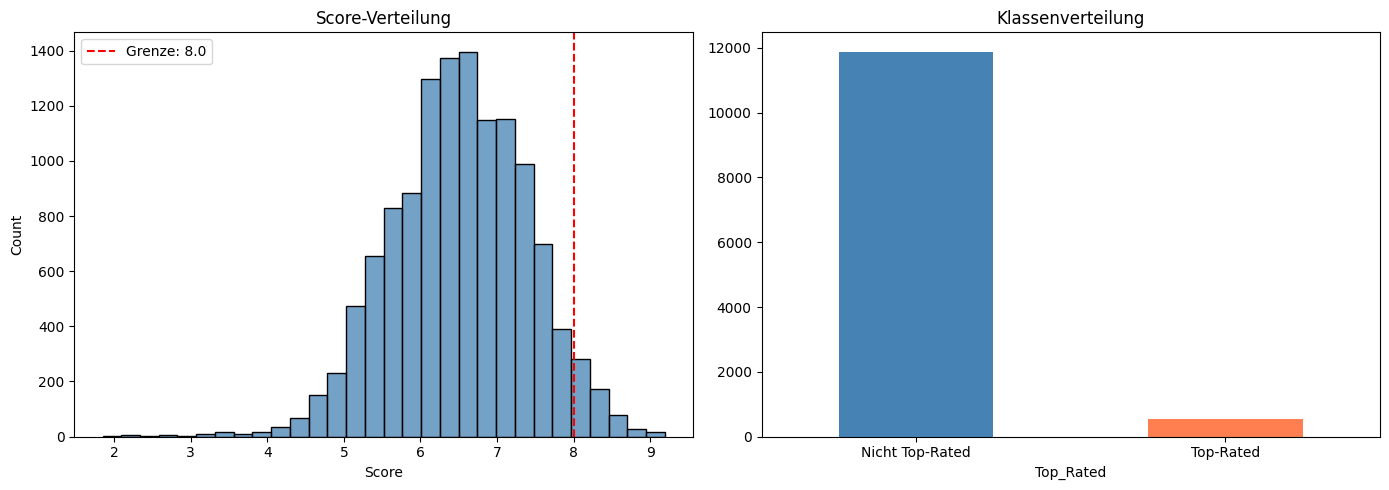

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score-Verteilung
sns.histplot(df_scored['Score'], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(x=8.0, color='red', linestyle='--', label='Grenze: 8.0')
axes[0].set_title('Score-Verteilung')
axes[0].legend()

# Klassen-Verteilung
df_scored['Top_Rated'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_xticklabels(['Nicht Top-Rated', 'Top-Rated'], rotation=0)
axes[1].set_title('Klassenverteilung')

plt.tight_layout()
plt.show()

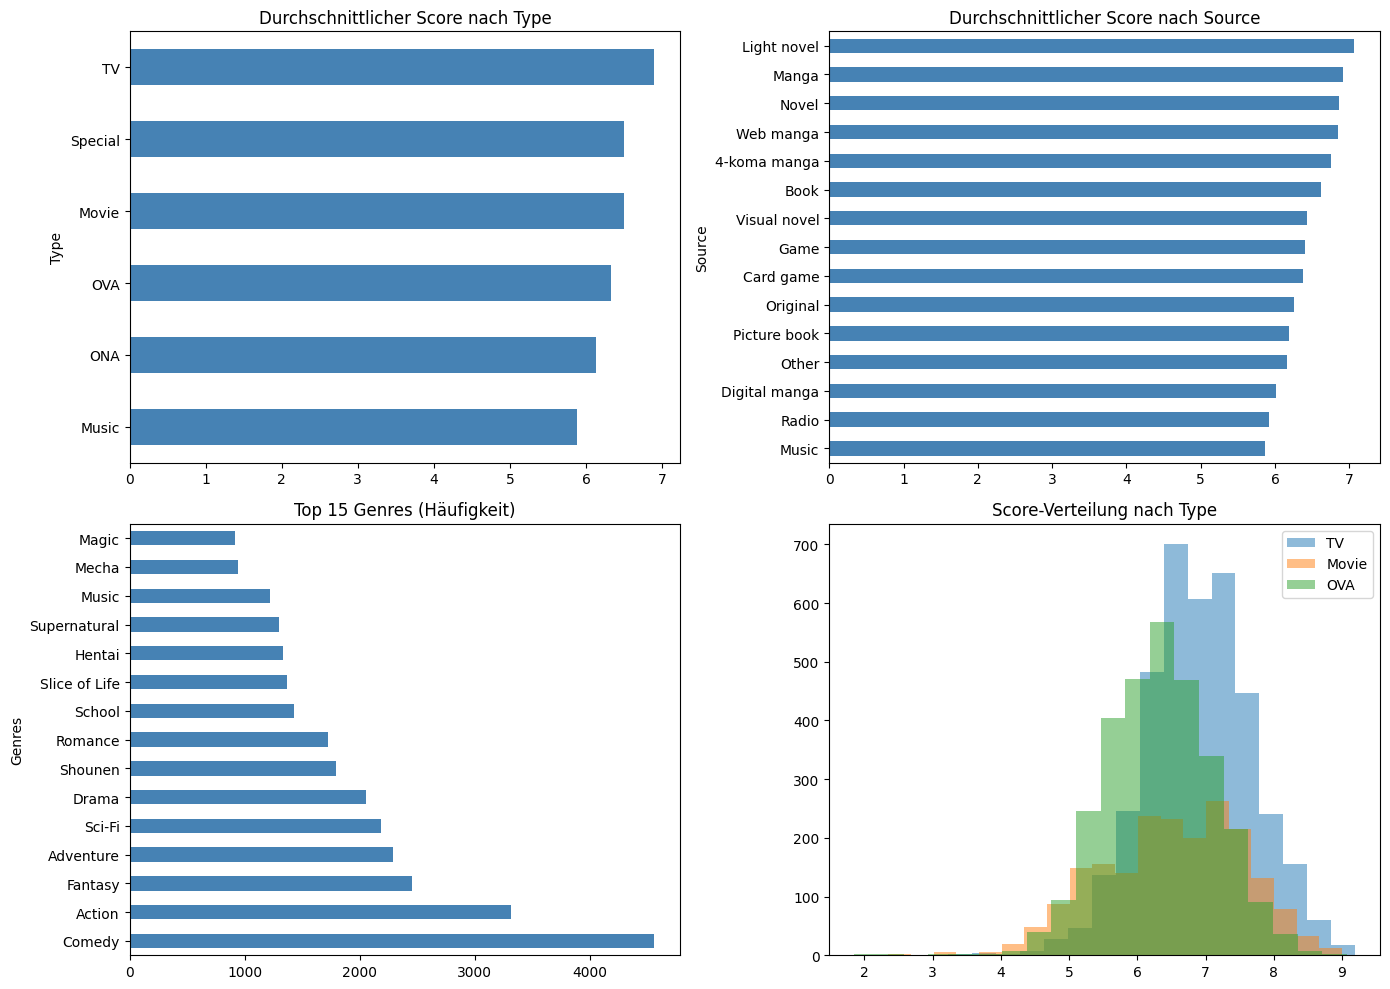

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score nach Type
df_scored.groupby('Type')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Durchschnittlicher Score nach Type')

# Score nach Source
df_scored.groupby('Source')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Durchschnittlicher Score nach Source')

# Top 15 Genres
all_genres = df_scored['Genres'].dropna().str.split(', ').explode()
all_genres.value_counts().head(15).plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Top 15 Genres (Häufigkeit)')

# Score-Verteilung nach Type
for t in ['TV', 'Movie', 'OVA']:
    subset = df_scored[df_scored['Type'] == t]['Score']
    axes[1,1].hist(subset, bins=20, alpha=0.5, label=t)
axes[1,1].set_title('Score-Verteilung nach Type')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering

Die Top-14-Genres werden als binäre Spalten (One-Hot) kodiert. Zusätzlich werden `Type` (TV/nicht-TV) und `Source` (Manga / Light Novel) als Indikatoren aufgenommen.  
`Members` und `Episodes` sind die einzigen kontinuierlichen Features.

In [136]:
# Top-Genres als eigene Spalten (One-Hot)
top_genres = ['Comedy', 'Action', 'Fantasy', 'Adventure', 'Sci-Fi', 
              'Drama', 'Shounen', 'Romance', 'School', 'Slice of Life',
              'Supernatural', 'Music', 'Mecha', 'Magic']

for genre in top_genres:
    df_scored[genre] = df_scored['Genres'].str.contains(genre, na=False).astype(int)

# Type und Source auch encoden
df_scored['is_TV'] = (df_scored['Type'] == 'TV').astype(int)
df_scored['is_Manga'] = (df_scored['Source'] == 'Manga').astype(int)
df_scored['is_LightNovel'] = (df_scored['Source'] == 'Light novel').astype(int)

print("Neue Spalten erstellt:")
print(df_scored[top_genres + ['is_TV', 'is_Manga', 'is_LightNovel']].sum().sort_values(ascending=False))

Neue Spalten erstellt:
Comedy           4559
is_TV            3837
is_Manga         3413
Action           3312
Fantasy          2452
Adventure        2288
Sci-Fi           2185
Drama            2051
Shounen          1887
Romance          1724
School           1433
Slice of Life    1370
Supernatural     1300
Music            1220
Mecha             946
Magic             918
is_LightNovel     709
dtype: int64


In [137]:
from sklearn.model_selection import train_test_split

# Features definieren
feature_cols = top_genres + ['is_TV', 'is_Manga', 'is_LightNovel', 'Episodes', 'Members']

# Zeilen mit fehlenden Werten in den Features entfernen
df_model = df_scored[feature_cols + ['Top_Rated']].dropna()

X = df_model[feature_cols]
y = df_model['Top_Rated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten:      {X_test.shape[0]} Zeilen")
print(f"Top-Rated im Training: {y_train.mean():.1%}")
print(f"Top-Rated im Test:     {y_test.mean():.1%}")

Trainingsdaten: 9852 Zeilen
Testdaten:      2464 Zeilen
Top-Rated im Training: 4.3%
Top-Rated im Test:     4.3%


## 4. Klassifikation

Binäre Klassifikation: Top-Rated (Score > 8.0) vs. Normal.  
Da die Klassen stark unbalanciert sind (4,3 % positiv), wird **SMOTE** eingesetzt, um synthetische Minority-Samples im Training zu erzeugen.  
Für die Logistic Regression wird ein **Pipeline** mit `StandardScaler` verwendet, da `Members` und `Episodes` eine deutlich andere Größenordnung als die binären Genre-Features haben.

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Baseline ohne SMOTE – StandardScaler nötig, da Members/Episodes andere Größenordnung als binäre Features
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== BASELINE (ohne SMOTE) ===")
print(classification_report(y_test, y_pred_baseline, target_names=['Normal', 'Top-Rated']))

=== BASELINE (ohne SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      2359
   Top-Rated       0.80      0.27      0.40       105

    accuracy                           0.97      2464
   macro avg       0.88      0.63      0.69      2464
weighted avg       0.96      0.97      0.96      2464



In [139]:
from imblearn.over_sampling import SMOTE

# SMOTE nur auf Trainingsdaten anwenden
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Vor SMOTE:  {y_train.value_counts().to_dict()}")
print(f"Nach SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

# Logistic Regression mit SMOTE + Skalierung via Pipeline
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_reg.fit(X_train_sm, y_train_sm)
y_pred_lr = log_reg.predict(X_test)

print("\n=== LOGISTIC REGRESSION (mit SMOTE) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Top-Rated']))

Vor SMOTE:  {0: 9431, 1: 421}
Nach SMOTE: {0: 9431, 1: 9431}

=== LOGISTIC REGRESSION (mit SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95      2359
   Top-Rated       0.27      0.64      0.38       105

    accuracy                           0.91      2464
   macro avg       0.63      0.78      0.67      2464
weighted avg       0.95      0.91      0.93      2464



In [140]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST (mit SMOTE) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Top-Rated']))

=== RANDOM FOREST (mit SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      2359
   Top-Rated       0.51      0.52      0.52       105

    accuracy                           0.96      2464
   macro avg       0.74      0.75      0.75      2464
weighted avg       0.96      0.96      0.96      2464



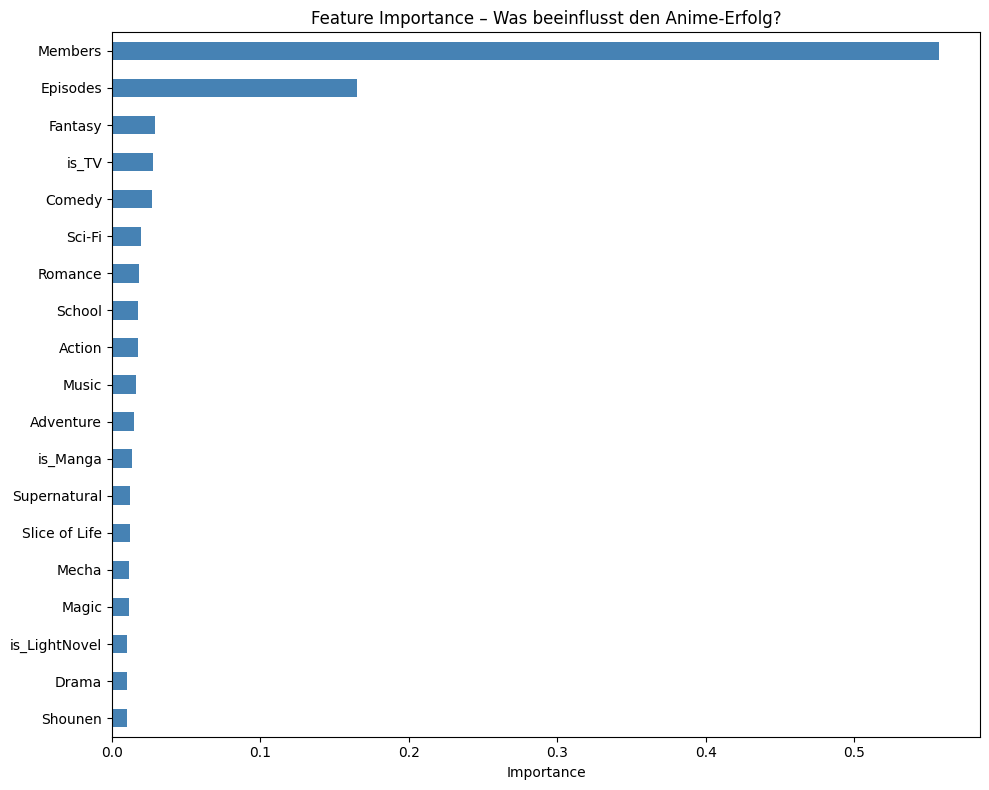


Top 5 Features:
Comedy      0.027053
is_TV       0.027373
Fantasy     0.029093
Episodes    0.165047
Members     0.556735
dtype: float64


In [141]:
# Feature Importance vom Random Forest
importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importance – Was beeinflusst den Anime-Erfolg?')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(importance_sorted.tail(5))

=== RANDOM FOREST OHNE MEMBERS ===
              precision    recall  f1-score   support

      Normal       0.97      0.87      0.92      2359
   Top-Rated       0.12      0.39      0.18       105

    accuracy                           0.85      2464
   macro avg       0.54      0.63      0.55      2464
weighted avg       0.93      0.85      0.89      2464



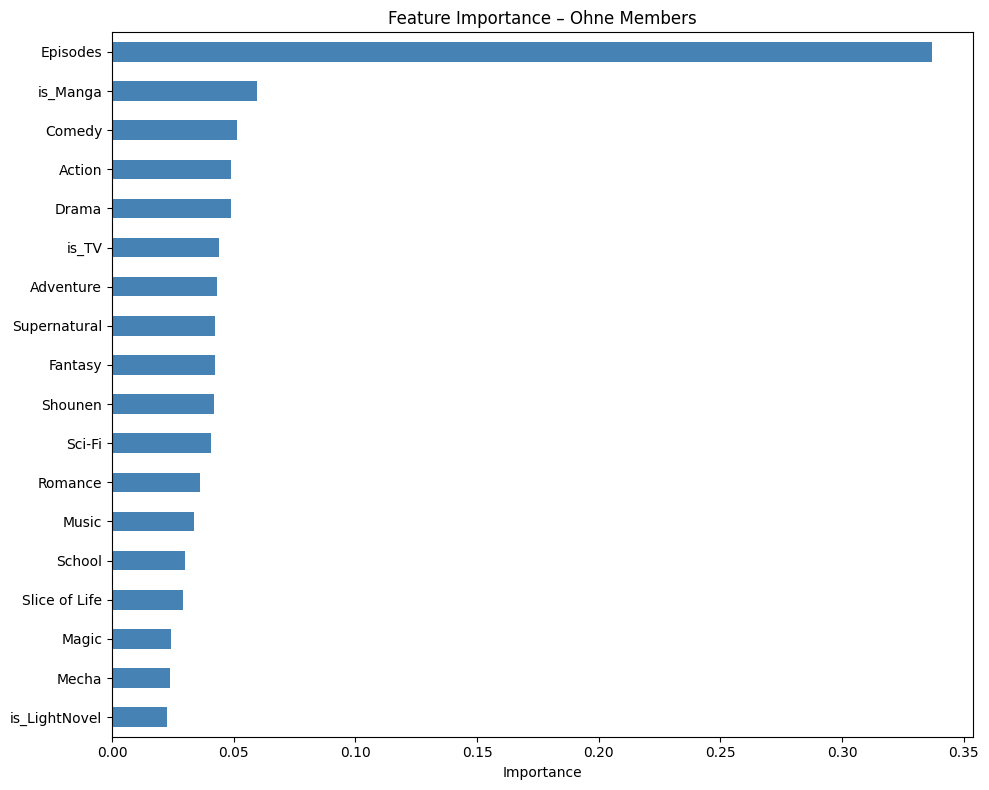

In [142]:
# Features ohne Members
feature_cols_clean = [c for c in feature_cols if c != 'Members']

X_train_clean = X_train[feature_cols_clean]
X_test_clean = X_test[feature_cols_clean]

# Neues SMOTE + Random Forest
X_train_sm2, y_train_sm2 = smote.fit_resample(X_train_clean, y_train)

rf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clean.fit(X_train_sm2, y_train_sm2)
y_pred_clean = rf_clean.predict(X_test_clean)

print("=== RANDOM FOREST OHNE MEMBERS ===")
print(classification_report(y_test, y_pred_clean, target_names=['Normal', 'Top-Rated']))

# Neue Feature Importance
importance_clean = pd.Series(rf_clean.feature_importances_, index=feature_cols_clean)
importance_clean.sort_values(ascending=True).plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Feature Importance – Ohne Members')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. Clustering & Empfehlungssystem

KMeans-Clustering auf Basis der Genre-, Type- und Source-Features (ohne Scores).  
Die Elbow-Methode legt **k=5** nahe. Auf Basis der Cluster-Zugehörigkeit werden ähnliche Anime empfohlen.

In [143]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features fürs Clustering: Genres + Type + Source
cluster_features = top_genres + ['is_TV', 'is_Manga', 'is_LightNovel']
X_cluster = df_scored[cluster_features].copy()

# Skalieren (wichtig für KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Anime im Clustering: {X_scaled.shape[0]}")
print(f"Features: {X_scaled.shape[1]}")

Anime im Clustering: 12421
Features: 17


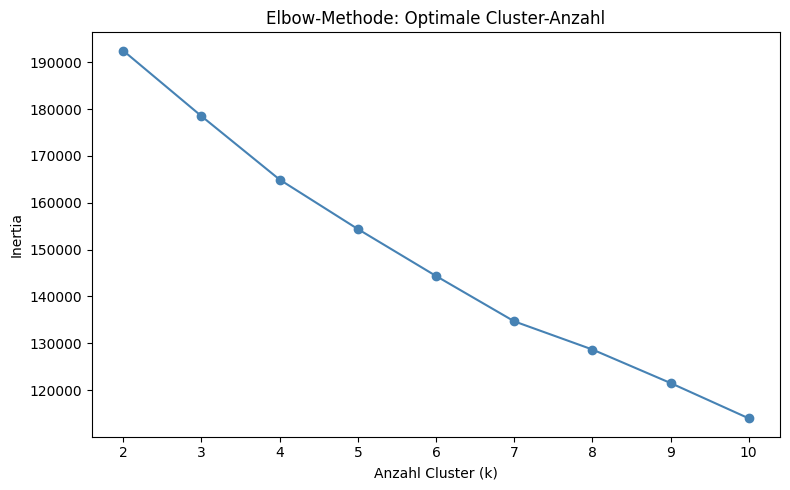

In [144]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow-Methode: Optimale Cluster-Anzahl')
plt.tight_layout()
plt.show()

In [145]:
# KMeans mit 5 Clustern
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_scored['Cluster'] = km_final.fit_predict(X_scaled)

# Was steckt in jedem Cluster?
cluster_profile = df_scored.groupby('Cluster')[top_genres].mean().round(2)
cluster_profile['Anzahl'] = df_scored['Cluster'].value_counts().sort_index()
cluster_profile['Avg_Score'] = df_scored.groupby('Cluster')['Score'].mean().round(2)

print(cluster_profile.T)

Cluster             0       1        2        3        4
Comedy           0.23    0.44     0.15     0.74     0.37
Action           0.63    0.39     0.04     0.05     0.65
Fantasy          0.08    0.60     0.10     0.05     0.40
Adventure        0.28    0.30     0.02     0.01     0.51
Sci-Fi           0.79    0.09     0.06     0.07     0.28
Drama            0.20    0.15     0.11     0.23     0.19
Shounen          0.21    0.15     0.02     0.19     0.30
Romance          0.09    0.20     0.04     0.37     0.08
School           0.03    0.11     0.03     0.39     0.01
Slice of Life    0.01    0.07     0.05     0.36     0.01
Supernatural     0.02    0.19     0.05     0.11     0.18
Music            0.03    0.03     0.23     0.03     0.00
Mecha            1.00    0.01     0.00     0.00     0.00
Magic            0.01    1.00     0.00     0.00     0.00
Anzahl         935.00  906.00  4652.00  2811.00  3117.00
Avg_Score        6.61    6.77     6.05     6.87     6.77


In [146]:
cluster_names = {
    0: 'Mecha & Sci-Fi',
    1: 'Fantasy & Magic',
    2: 'Allgemein / Nische',
    3: 'Romantic Comedy / Alltag',
    4: 'Battle Shounen'
}
df_scored['Cluster_Name'] = df_scored['Cluster'].map(cluster_names)


def find_anime(name):
    return df_scored[df_scored['Name'].str.contains(name, case=False, na=False)][
        ['Name', 'Score', 'Genres', 'Cluster_Name']
    ]


def empfehlung(anime_name, n=5):
    treffer = find_anime(anime_name)

    if treffer.empty:
        print(f"Kein Anime mit '{anime_name}' gefunden.")
        return

    if len(treffer) > 1:
        print(f"{len(treffer)} Treffer für '{anime_name}':")
        print(treffer[['Name', 'Score']].to_string(index=False))
        print(f"\n→ Verwende ersten Treffer: '{treffer.iloc[0]['Name']}'")
        print("  (Präziserer Name für eindeutigen Treffer möglich)\n")

    anime = df_scored.loc[treffer.index[0]]
    cluster = anime['Cluster']
    print(f"'{anime['Name']}' → Cluster: {cluster_names[cluster]}")
    print(f"\nÄhnliche Anime (Top {n} nach Score):")
    similar = df_scored[(df_scored['Cluster'] == cluster) & (df_scored['Name'] != anime['Name'])]
    return similar.nlargest(n, 'Score')[['Name', 'Score', 'Genres', 'Cluster_Name']]


empfehlung('Shingeki no Kyojin', 11)

18 Treffer für 'Shingeki no Kyojin':
                                                     Name  Score
                                       Shingeki no Kyojin   8.48
                                   Shingeki no Kyojin OVA   7.83
                          Shingeki no Kyojin: Ano Hi Kara   7.14
                         Shingeki no Kyojin Picture Drama   6.63
              Shingeki no Kyojin Movie 1: Guren no Yumiya   7.64
             Shingeki no Kyojin Movie 2: Jiyuu no Tsubasa   7.74
                              Shingeki no Kyojin Season 2   8.45
                      Shingeki no Kyojin: Kuinaki Sentaku   8.38
               Shingeki no Kyojin-ten 360° Taikan Theater   7.13
                              Shingeki no Kyojin Season 3   8.59
                           Shingeki no Kyojin: Lost Girls   7.75
     Shingeki no Kyojin Season 2 Movie: Kakusei no Houkou   7.76
            Animegatari x Shingeki no Kyojin Collab Eizou   6.52
                       Shingeki no Kyojin Season 3 Pa

,Name,Score,Genres,Cluster_Name
15926,Shingeki no Kyojin: The Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",Battle Shounen
6474,Hunter x Hunter (2011),9.10,"Action, Adventure, Fantasy, Shounen, Super Power",Battle Shounen
9913,Gintama°,9.10,"Action, Comedy, Historical, Parody, Samurai, S...",Battle Shounen
14963,Shingeki no Kyojin Season 3 Part 2,9.10,"Action, Drama, Fantasy, Military, Mystery, Sho...",Battle Shounen
6006,Gintama',9.08,"Action, Sci-Fi, Comedy, Historical, Parody, Sa...",Battle Shounen
7261,Gintama': Enchousen,9.04,"Action, Comedy, Historical, Parody, Samurai, S...",Battle Shounen
12242,Gintama.,8.99,"Action, Comedy, Historical, Parody, Samurai, S...",Battle Shounen
833,Gintama,8.96,"Action, Comedy, Historical, Parody, Samurai, S...",Battle Shounen
7249,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,8.96,"Action, Sci-Fi, Comedy, Historical, Parody, Sa...",Battle Shounen
15631,Gintama: The Final,8.88,"Action, Sci-Fi, Comedy, Historical, Parody, Dr...",Battle Shounen


In [147]:
# Beispiel: Suche nach einem Anime (Teilstring genügt, Groß-/Kleinschreibung egal)
find_anime('vinland')

,Name,Score,Genres,Cluster_Name
14313,Vinland Saga,8.71,"Action, Adventure, Drama, Historical, Seinen",Battle Shounen


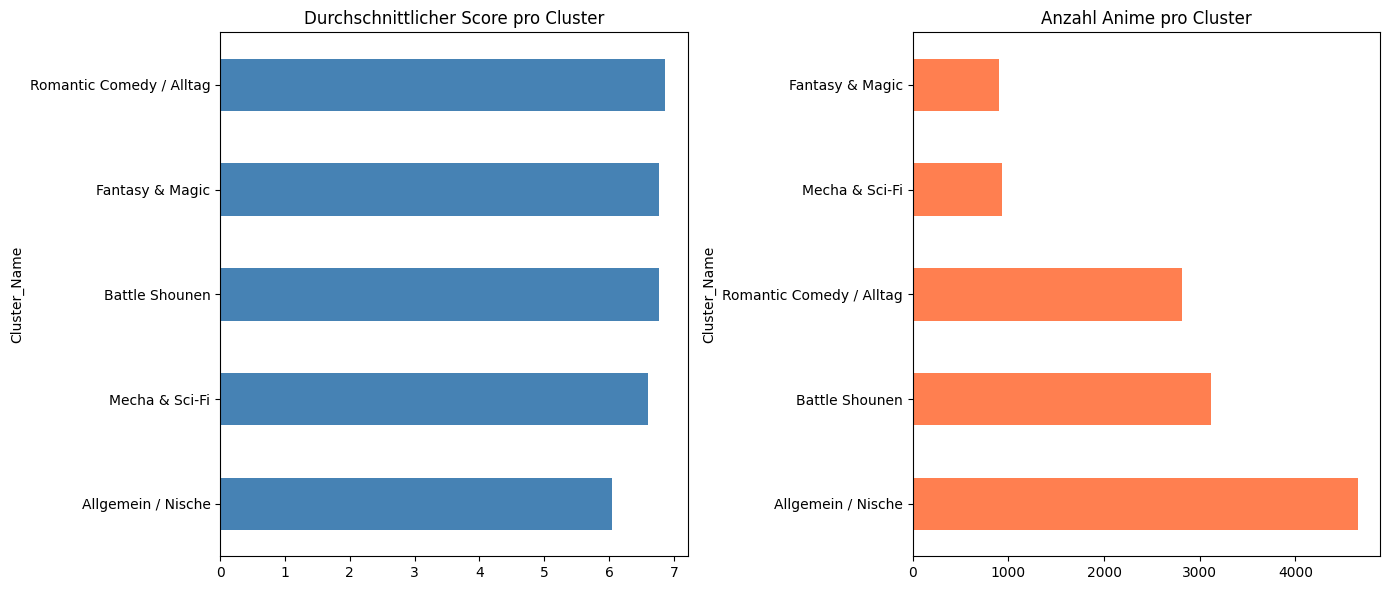

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cluster-Verteilung mit Scores
df_scored.groupby('Cluster_Name')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Durchschnittlicher Score pro Cluster')

# Cluster-Größen
df_scored['Cluster_Name'].value_counts().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Anzahl Anime pro Cluster')

plt.tight_layout()
plt.show()

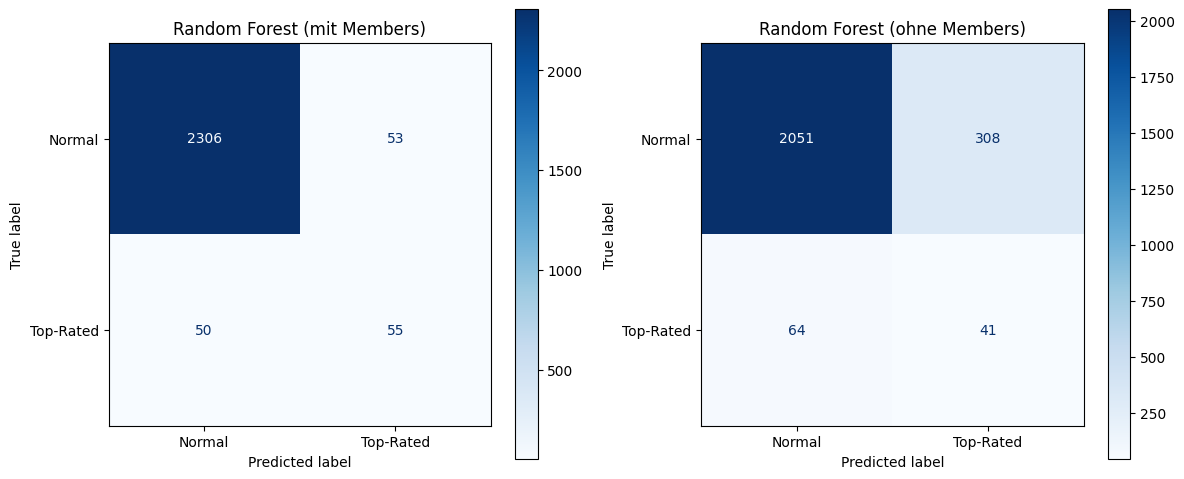

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mit Members
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, 
    display_labels=['Normal', 'Top-Rated'], ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest (mit Members)')

# Ohne Members
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clean, 
    display_labels=['Normal', 'Top-Rated'], ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest (ohne Members)')

plt.tight_layout()
plt.show()

In [150]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_sm, y_train_sm)

print(f"Beste Parameter: {grid_search.best_params_}")
print(f"Bester F1-Score (CV): {grid_search.best_score_:.3f}")

# Bestes Modell auf Testdaten
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print(f"\n=== TUNED RANDOM FOREST ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Top-Rated']))

Beste Parameter: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Bester F1-Score (CV): 0.971

=== TUNED RANDOM FOREST ===
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      2359
   Top-Rated       0.50      0.50      0.50       105

    accuracy                           0.96      2464
   macro avg       0.74      0.74      0.74      2464
weighted avg       0.96      0.96      0.96      2464



## 6. Ergebnisse & Fazit

- **SMOTE** verbessert den Recall für Top-Rated erheblich (26 % → 66 % bei Logistic Regression), senkt aber Precision deutlich
- **Random Forest** liefert das beste Gleichgewicht (F1 = 0.52) – ohne Members bricht die Performance ein (F1 = 0.18)
- **Members** ist mit ~55 % Feature Importance der dominante Prädiktor, stellt aber eine zirkuläre Abhängigkeit dar
- **Inhaltliche Merkmale** (Genre, Type, Source) allein reichen nicht aus, um Anime-Erfolg zuverlässig vorherzusagen
- **Clustering** ergibt 5 interpretierbare Gruppen, die für ein einfaches Empfehlungssystem genutzt werden können